<a href="https://colab.research.google.com/github/Tiago150196/analise-vendas-negocio/blob/main/Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🌍 Análise Global das Emissões de CO₂ (1750–2021): Tendências, Países e Fontes

# 🌍 Análise de Emissões de CO₂

## 🎯 Objetivo
Breve explicação

## 📊 Principais análises
- Top países emissores
- Evolução ao longo do tempo
- Fontes de emissão
- Emissão per capita

## 💡 Principais insights
- Crescimento acelerado após 1950
- Combustíveis fósseis dominam
- Concentração em poucos países

## 🛠️ Tecnologias
- Python
- Pandas
- Matplotlib / Seaborn

## 🎯 Objetivo
Analisar as emissões de CO2 ao longo do tempo para identificar padrões, principais países emissores e fontes de emissão, apoiando decisões relacionadas a sustentabilidade e políticas ambientais.

## ❓ Perguntas de negócio
- Quais países mais emitem CO2 atualmente?
- Como as emissões evoluíram ao longo do tempo?
- Quais fontes (carvão, gás, petróleo) são mais relevantes?
- Houve aceleração nas últimas décadas?

📥 Importação de dados (Excel)
Os dados foram obtidos a partir de uma planilha no formato Excel (.xlsx), contendo informações sobre emissões de CO2 por país ao longo dos anos.
O arquivo foi carregado utilizando a função read_excel() da biblioteca Pandas.

❓ Perguntas de negócio
* Quais países mais emitem CO2?
* Como as emissões evoluíram ao longo dos anos?
* Quais fontes de emissão são mais relevantes?
* Existe aumento significativo nas últimas décadas?


📥 2. Importação de dados

In [32]:
import pandas as pd

url = 'https://github.com/alura-cursos/Pandas/blob/main/emissoes_CO2.xlsx?raw=True'

dados = pd.read_excel(url, sheet_name='emissoes_C02')
percapita = pd.read_excel(url, sheet_name='emissoes_percapita')
fontes = pd.read_excel(url, sheet_name='fontes')

🧹 3. Limpeza de dados

In [33]:
# substituir [NONE] por NaN
fontes = fontes.replace('[NONE]', pd.NA)

# converter colunas numéricas
colunas = ['Total', 'Carvão', 'Oléo', 'Gás', 'Cimento', 'Queima', 'Outro']

for col in colunas:
    fontes[col] = pd.to_numeric(fontes[col], errors='coerce')

# remover valores nulos importantes
dados = dados.dropna(subset=['Total'])

# remover "Global" para análise por país
dados = dados[dados['País'] != 'Global']

📊 4. Análise Exploratória (EDA)

## 🌍 Principais Países Emissores

A análise mostra que poucos países concentram a maior parte das emissões globais.

China e Estados Unidos lideram com grande diferença em relação aos demais, seguidos por Índia, Rússia e Japão.

Esse padrão indica que políticas ambientais nesses países têm impacto significativo no cenário global.

In [34]:
top_paises = (
    dados[dados['Ano'] == dados['Ano'].max()]
    .sort_values('Total', ascending=False)
    .head(10)
)

top_paises[['País', 'Total']]

,País,Total
10879,China,1.147237e+10
60111,Estados Unidos,5.007336e+09
25567,Índia,2.709684e+09
47327,Rússia,1.755547e+09
27743,Japão,1.067398e+09
62831,Transporte internacional,1.021749e+09
26655,Irã,7.488788e+08
21487,Alemanha,6.747536e+08
49503,Arábia Saudita,6.723799e+08
25839,Indonésia,6.192775e+08


📈 Evolução global

## 📊 Interpretação da Evolução das Emissões

Observa-se um crescimento lento nas emissões até aproximadamente o século XX.

A partir de 1950, há um aumento acelerado, indicando o impacto da industrialização e do aumento do consumo de energia em escala global.

Esse comportamento sugere uma relação direta entre desenvolvimento econômico e aumento das emissões de CO₂.

<Axes: title={'center': 'Emissões Globais ao longo do tempo'}, xlabel='Ano'>

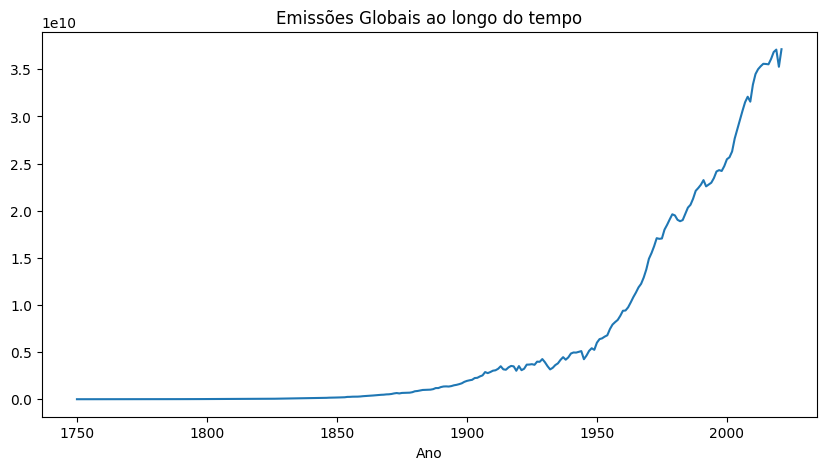

In [35]:
global_emissoes = (
    dados.groupby('Ano')['Total']
    .sum()
)

global_emissoes.plot(figsize=(10,5), title='Emissões Globais ao longo do tempo')

⛽ Fontes de emissão

## ⛽ Interpretação das Fontes de Emissão

As principais fontes de emissão de CO₂ são os combustíveis fósseis, com destaque para:

- Carvão
- Petróleo
- Gás natural

Essas fontes dominam ao longo do tempo, indicando forte dependência energética global desses recursos.

A análise reforça a necessidade de transição para fontes renováveis.

In [36]:
fontes_totais.head()

,Carvão,Oléo,Gás,Cimento,Queima,Outro
Ano,,,,,,
1750,9350528.0,0.0,0.0,0.0,0.0,0.0
1751,9350528.0,0.0,0.0,0.0,0.0,0.0
1752,9354192.0,0.0,0.0,0.0,0.0,0.0
1753,9354192.0,0.0,0.0,0.0,0.0,0.0
1754,9357856.0,0.0,0.0,0.0,0.0,0.0


<Axes: title={'center': 'Fontes de emissão ao longo do tempo'}, xlabel='Ano'>

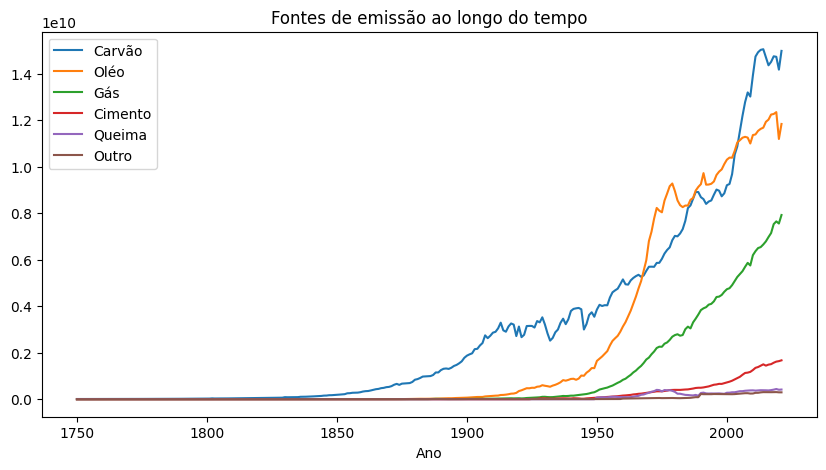

In [37]:
colunas = ['Carvão', 'Oléo', 'Gás', 'Cimento', 'Queima', 'Outro']

fontes_totais = (
    dados.groupby('Ano')[colunas]
    .sum()
)

fontes_totais.plot(figsize=(10,5), title='Fontes de emissão ao longo do tempo')

🤖 6. Modelo preditivo

## 🤖 Interpretação do Modelo Preditivo

O modelo de regressão linear indica uma tendência contínua de crescimento das emissões de CO₂ nos próximos anos.

No entanto, é importante destacar que o modelo é simplificado e não considera fatores externos como políticas ambientais, avanços tecnológicos ou mudanças no consumo de energia.

In [38]:
LinearRegression()

LinearRegression()

In [39]:
from sklearn.linear_model import LinearRegression

# prever emissão global
df_modelo = global_emissoes.reset_index()

X = df_modelo[['Ano']]
y = df_modelo['Total']

modelo = LinearRegression()
modelo.fit(X, y)

# previsão
futuro = pd.DataFrame({'Ano': [2030, 2040, 2050]})
modelo.predict(futuro)

array([2.12496783e+10, 2.22783315e+10, 2.33069847e+10])

## 🌍 Evolução dos principais emissores

Observa-se que países como China e Estados Unidos apresentam crescimento significativo ao longo do tempo.

A China apresenta forte aceleração recente, enquanto os Estados Unidos mostram uma tendência mais estável.

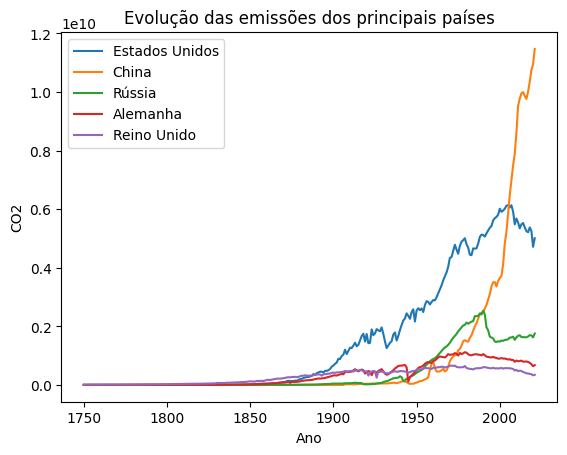

In [40]:
top5 = (
    dados.groupby('País')['Total']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

df_top5 = dados[dados['País'].isin(top5)]

import matplotlib.pyplot as plt

for pais in top5:
    df_pais = df_top5[df_top5['País'] == pais]
    plt.plot(df_pais['Ano'], df_pais['Total'], label=pais)

plt.legend()
plt.title('Evolução das emissões dos principais países')
plt.xlabel('Ano')
plt.ylabel('CO2')
plt.show()

🚀 2. 📈 Crescimento percentual

## 📈 Crescimento das emissões

A taxa de crescimento mostra períodos de aceleração e desaceleração das emissões globais.

Isso permite identificar momentos críticos, como crescimento industrial ou crises econômicas.

<Axes: title={'center': 'Crescimento percentual anual das emissões'}, xlabel='Ano'>

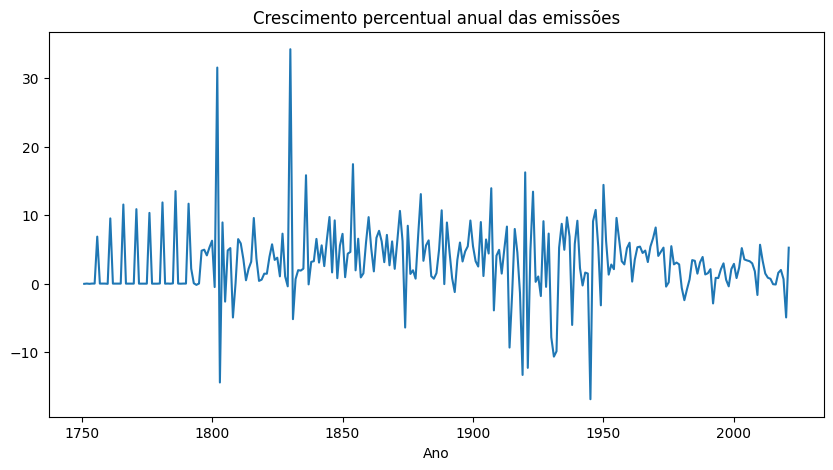

In [41]:
global_emissoes = dados.groupby('Ano')['Total'].sum()

crescimento = global_emissoes.pct_change() * 100

crescimento.plot(figsize=(10,5), title='Crescimento percentual anual das emissões')

🚀 3. 🧍 Emissão per capita

## 🧍 Emissões per capita

Ao analisar emissões per capita, países menores podem apresentar valores elevados, indicando alto consumo individual de energia.

Essa métrica é importante para avaliar responsabilidade individual e eficiência energética.

<Axes: title={'center': 'Top países por emissão per capita'}, xlabel='País'>

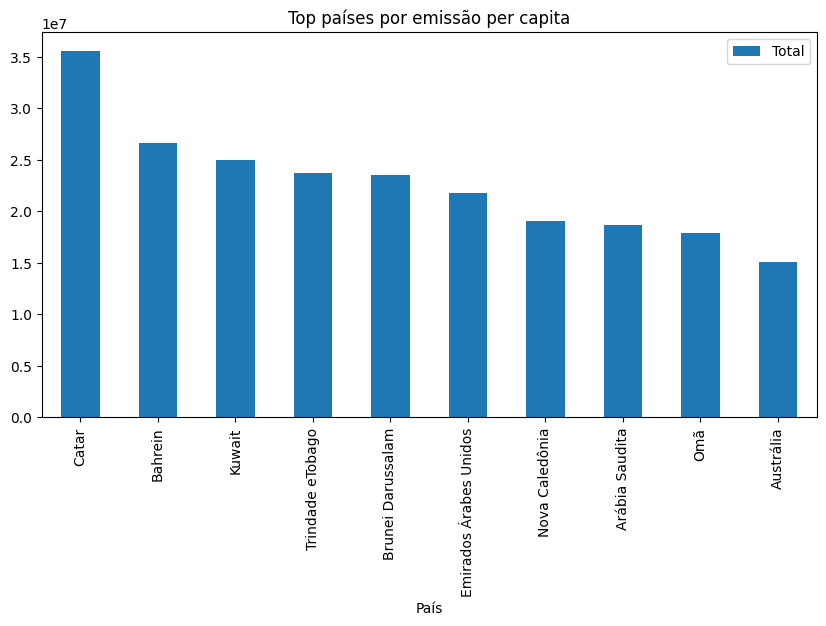

In [42]:
top_percapita = (
    percapita[percapita['Ano'] == percapita['Ano'].max()]
    .sort_values('Total', ascending=False)
    .head(10)
)

top_percapita.plot(kind='bar', x='País', y='Total', figsize=(10,5), title='Top países por emissão per capita')

🚀 4. 🔥 Heatmap de correlação

## 🔗 Correlação entre fontes de emissão

Observa-se forte correlação entre combustíveis fósseis e o total de emissões, indicando que essas fontes são os principais drivers do aumento de CO₂.

<Axes: >

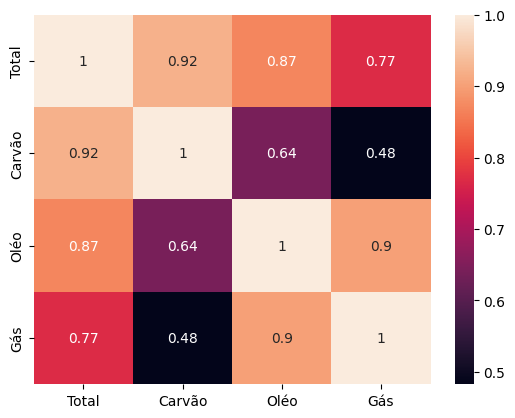

In [43]:
import seaborn as sns

corr = dados[['Total', 'Carvão', 'Oléo', 'Gás']].corr()

sns.heatmap(corr, annot=True)

📊 Ranking ao longo do tempo (top 1 por ano)

In [44]:
top_por_ano = (
    dados.sort_values(['Ano', 'Total'], ascending=[True, False])
    .groupby('Ano')
    .first()
)

top_por_ano['País'].value_counts().head(10)

,count
País,
Reino Unido,139
Estados Unidos,117
China,16


🚀 1. 🥧 Participação das fontes

## 📊 Participação das fontes de emissão

Ao analisar a participação percentual, observa-se que os combustíveis fósseis dominam a composição das emissões ao longo do tempo.

Mesmo com mudanças tecnológicas, a dependência global dessas fontes permanece significativa.

<Axes: title={'center': 'Participação das fontes de emissão (%)'}, xlabel='Ano'>

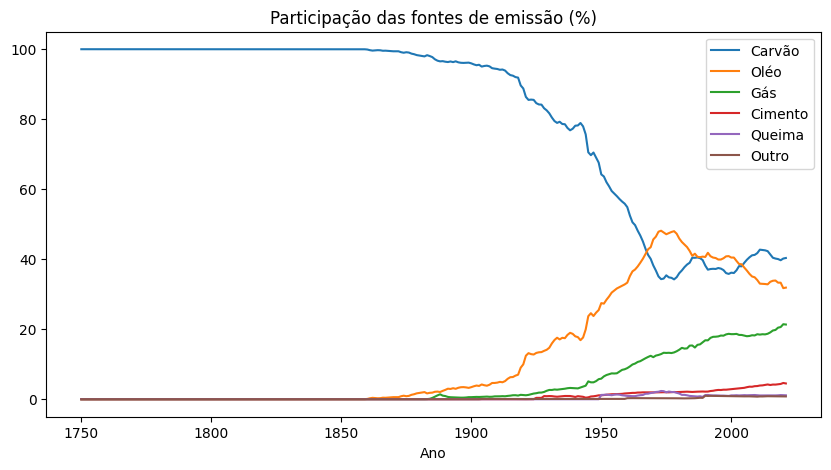

In [45]:
fontes_percentual = fontes_totais.div(fontes_totais.sum(axis=1), axis=0) * 100

fontes_percentual.plot(figsize=(10,5), title='Participação das fontes de emissão (%)')

🚀 2. 🌍 Top países por década

## 🏆 Liderança ao longo das décadas

A análise por década mostra como a liderança nas emissões mudou ao longo do tempo.

Países industrializados dominaram inicialmente, enquanto economias emergentes ganharam relevância nas últimas décadas.

In [46]:
dados['Década'] = (dados['Ano'] // 10) * 10

top_decada = (
    dados.sort_values(['Década', 'Total'], ascending=[True, False])
    .groupby('Década')
    .first()
)

top_decada['País'].value_counts()

,count
País,
Reino Unido,13
Estados Unidos,12
China,3


🚀 3. 📦 Boxplot por país (distribuição)

## 📦 Distribuição das emissões

O boxplot evidencia a variabilidade das emissões ao longo do tempo para os principais países.

Alguns países apresentam maior volatilidade, enquanto outros possuem crescimento mais consistente.

<Axes: xlabel='País', ylabel='Total'>

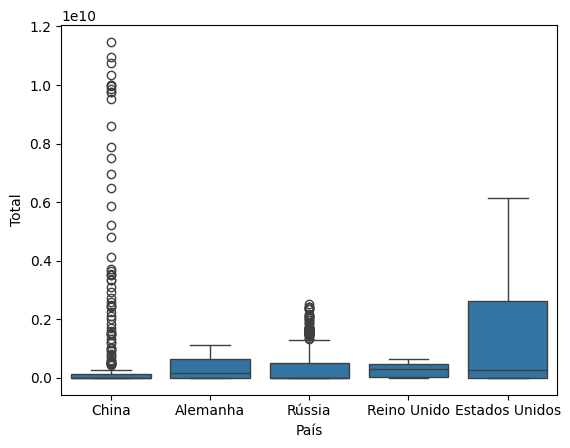

In [47]:
import seaborn as sns

top5 = dados.groupby('País')['Total'].sum().nlargest(5).index
df_box = dados[dados['País'].isin(top5)]

sns.boxplot(data=df_box, x='País', y='Total')

🚀 4. 🔥 Média móvel

## 📉 Tendência das emissões

A média móvel suaviza oscilações de curto prazo e evidencia a tendência estrutural de crescimento das emissões globais.

<Axes: title={'center': 'Tendência das emissões (média móvel)'}, xlabel='Ano'>

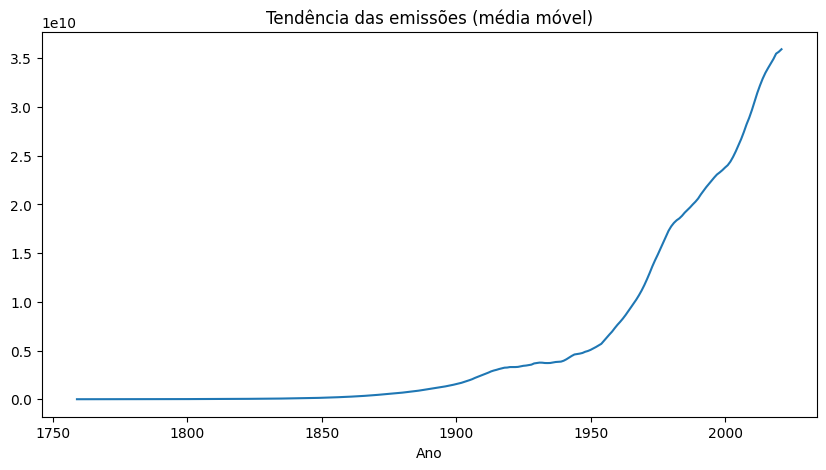

In [48]:
global_emissoes_ma = global_emissoes.rolling(10).mean()

global_emissoes_ma.plot(figsize=(10,5), title='Tendência das emissões (média móvel)')

🚀 5. ⚠️ Identificar anos de maior crescimento

## 🚀 Picos de crescimento

Os anos com maior crescimento percentual indicam períodos de forte expansão econômica ou aumento do consumo energético.

Esses momentos são críticos para entender o comportamento das emissões.

In [49]:
top_crescimento = crescimento.sort_values(ascending=False).head(10)
top_crescimento

,Total
Ano,
1830,34.231000
1802,31.555497
1854,17.462299
1920,16.261943
1836,15.843630
1950,14.438512
1907,13.949128
1786,13.531712
1923,13.447459


📌 5. Insights
Exemplo:
Emissões cresceram exponencialmente após 1950
Carvão e petróleo são os maiores responsáveis
Poucos países concentram a maior parte da emissão
Crescimento acelerado nas últimas décadas

## 📌 Conclusão Final

Os dados evidenciam uma tendência estrutural de crescimento das emissões de CO₂, impulsionada principalmente pelo uso de combustíveis fósseis.

A concentração das emissões em poucos países reforça a importância de políticas direcionadas e cooperação internacional.

Além disso, a análise histórica sugere que, sem intervenções significativas, a tendência de crescimento tende a se manter nas próximas décadas.

Os resultados indicam que políticas públicas e inovação energética serão determinantes para alterar a trajetória futura das emissões.